<div style="display:none">
$$
\newcommand{\rvar}[1]{\mathrm{#1}}
\newcommand{\rvec}[1]{\mathbf{#1}}
\newcommand{\vec}[1]{\pmb{#1}}
\newcommand{\tens}[1]{\pmb{\mathsf{#1}}}
\newcommand{\tensel}[1]{\mathsf{#1}}
\newcommand{\st}[1]{\mathcal{#1}}
\newcommand{\diag}[1]{\mathrm{diag}(\vec{#1})}
$$
</div>

In [1]:
# some initialization stuff
%run ../init.py
%matplotlib inline

<IPython.core.display.Latex object>

In [2]:
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_blobs
from sklearn import svm

cm = ListedColormap(['green', 'blue'])

def get_boundaries(X):
    # compute plot boundaries
    xlim = (np.min(X[:, 0]-1),np.max(X[:, 0]+1))
    ylim = (np.min(X[:, 1]-1),np.max(X[:, 1]+1))
    return xlim, ylim

def plot(m, p, xlim, ylim):
    # generate grid for plots of decision models
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    Z = m.decision_function(xy).reshape(XX.shape)

    # plot decision boundary and margins (values of Z) on XX YY
    # XX and YY are coordinates of values in Z
    p.contour(XX, YY, Z, colors=['blue','black'], levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'], corner_mask=True)
    # indicate support vectors
    p.scatter(m.support_vectors_[:, 0], m.support_vectors_[:, 1], facecolors='none', edgecolors='r')

# Support Vector Machines

## Let's separate the points
- Approach the two-class classification problem in a
direct way:

<p class="fragment step-fade-in myalert"> 
Try to find a plane that separates the classes in feature space
</p>

- If the problem above cannot be solved, we try two things:
    + Soften what we mean by "separates", and
    + Enrich and enlarge the feature space so that separation is possible

## Hyperplanes

- A hyperplane in $p$ dimensions is a at affine subspace of
dimension $p-1$
    + Line if $p=1$, plane for $p=2$, etc.
    + Affine subspace is a geometric structure need not to pass through the origin
- In general the equation for a hyperplane has the form

$$ w_0 + w_1 x_1 + w_2 x_2 + \dots + w_p x_p = 0 $$

- If $w_0 = 0$, then the hyperplane goes through the origin, otherwise not
- The vector $\vec{w} = [w_1, \dots, w_p]^\top$ is called the normal vector since it points in a direction orthogonal to the surface of a hyperplane

## Separating hyperplanes

- If $f(\vec{x} \mid w_0,\vec{w}) = w_0 + \vec{w}^\top \vec{x}$, where $w_0$ and $\vec{w}$ are parameters of a model, then 
    + $f(\vec{x}) > 0$ for points on one side of the hyperplane, and 
    + $f(\vec{x}) < 0$ for points on the other
- Let us label the blue points as $y_i = 1$ and $y_j = -1$ for green
- If $y_i \cdot f(x_i) > 0$  where  $1 \leq i \leq N$, then $f(\vec{x}) = 0$ defines a separating hyperplane

In [3]:
# generates data set (two Gaussians) for visualization purposes
X, y = make_blobs(n_samples=40, centers=2, cluster_std=(1,1), random_state=3)
xlim, ylim = get_boundaries(X)
    
def sep_plane(show=False):
    plt.figure(figsize=(5,5))
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cm)

    if not show:
        plt.plot(xlim,[ylim[1]-2, ylim[0]+2], "-c")
        plt.plot(xlim,[ylim[1]+1, ylim[0]-2], "-r")
    else:
        plt.plot(xlim, [ylim[1], ylim[0]], "-k")
        plt.fill_between(xlim, [ylim[1], ylim[0]], ylim[0], alpha=.1, color='blue');
    plt.show()

In [4]:
interact(sep_plane);

interactive(children=(Checkbox(value=False, description='show'), Output()), _dom_classes=('widget-interact',))

### Vector norms

- Often when we work with vectors, we would like to measure the distance from the origin to the end of the vector
- Norm of a vector $\vec{x}$ is a function that maps a vector to a real number:
    $$\lVert\vec{x}\rVert_p = \left( \sum_i |x_i|^p\right)^\frac{1}{p}$$
    - Manhattan norm: $p=1$
    - Euclidean norm (length of a vector): $p=2$

## Maximal margin classifier
- Many different separating hyperplanes can exist
- Select the one that has the maximal gap between the classes
- Optimization problem finding a boundary $M \in \mathbb{R}$:

\begin{align*}
    & \max_{\vec{w}} M  \text{ subject to constraints} \\
    &\\
    & \lVert\vec{w}\rVert_2^2 = 1  \\
    &\\
    & y_i\cdot f(x_i \mid \vec{w}) \geq M \text{ for }  1 \leq i \leq N
\end{align*}

- Note $\lVert\vec{w}\rVert_2^2$ denotes the squared $L^2$ norm, i.e., squared Euclidean distance
- Corresponds to a convex quadratic program (NP-hard in most cases)
  - `libsvm` is the most popular implementation
  - `svm.SVC` class in `sklearn`
  - `svm()` in package `e1071` (TU Wien) solves it efficiently (Greedy Coordinate Descent)

## Support vectors

- The observations (p-dimensional vectors) defining the margin are called the **support vectors**
- Example, two observations on the margins are support vectors in a 2-dimensional space

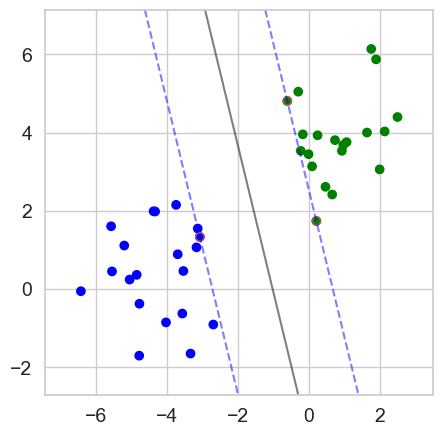

In [5]:
fig = plt.figure(figsize=(5,5))
plt.xlim(xlim)
plt.ylim(ylim)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cm)

# fit the model
m = svm.SVC(kernel='linear')
m.fit(X, y)

plot(m, plt, xlim, ylim)

## Support vector classifier

- Problems:
  - Real-world data is often non-separable with a linear plane 
  - In case of noise the performance of maximal margin classifier can also be quite poor

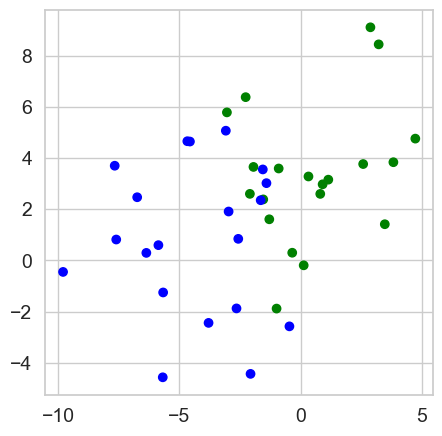

In [6]:
# generates data set (two Gaussians) for visualization purposes
X_m, y_m = make_blobs(n_samples=40, centers=2, cluster_std=(2.5,2.5), random_state=3)
xlim_m, ylim_m = get_boundaries(X_m)
fig = plt.figure(figsize=(5,5))
plt.scatter(X_m[:, 0], X_m[:, 1], c=y_m, cmap=cm);

- Solution: 
    - **Support vector classifier** maximizes a soft margin
    - *Soft margin* allows some of the observation to be on the incorrect side of the margin or even of the boundary

## Support vector classifier

- **Regularization parameter** $C$
  - Informally: determines how sensitive is the training algorithm to possible "mistakes" while solving the optimization problem
  - Each element $\epsilon_i$ of the vector $\vec{\epsilon}$ determines by how much the corresponding observation $x_i$ might be behind the margin 

- Optimization problem: 

\begin{align*}
    & \max_{\vec{w}, \vec{\epsilon}} M 
     \text{  subject to constraints} \\
    & \\
    & \lVert\vec{w}\rVert_2^2 = 1  \\
    & \\
    & y_if(x_i \mid \vec{w}) \geq M(1-\epsilon_i) ~~~\text{for}~~~  1 \leq i \leq N \\
    & \\
    & \sum_i{\epsilon_i}\leq C ~~\text{ and }~~ \epsilon_i > 0 
\end{align*}



## Example: Regularization parameter

- `SVC` implementation in `sklearn`:
    - Redefined optimization problem that uses $L^2$ norm as the penalty, i.e., $C\lVert\vec{\epsilon}\rVert_2^2 \leq 1$
- Smaller values of the regularization parameter allow for the inclusion of more outliers in the margins

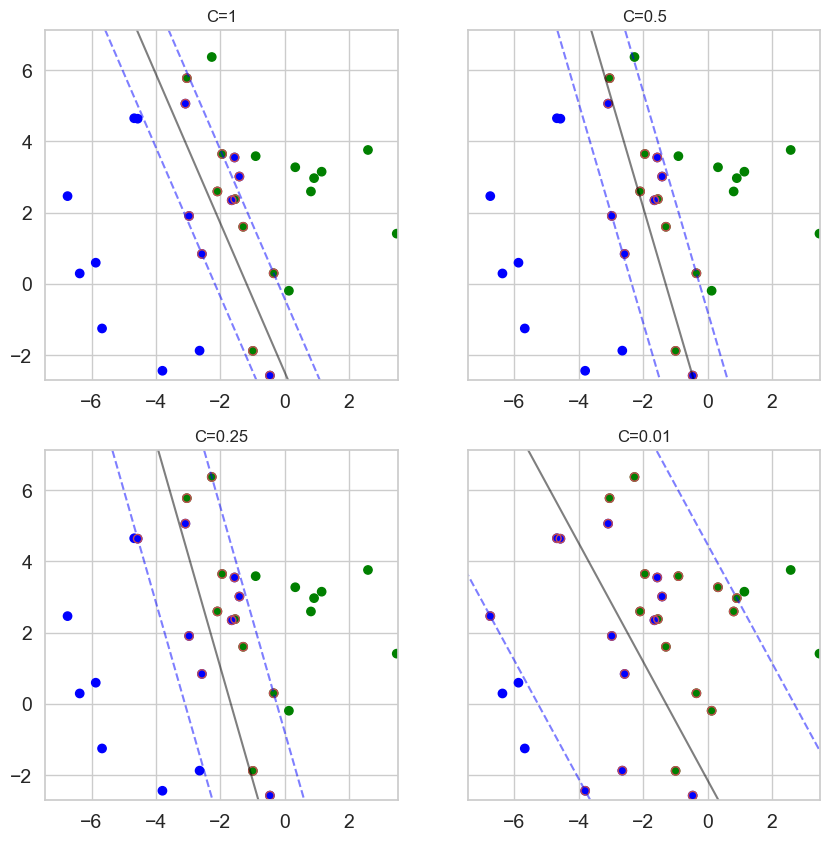

In [7]:
C=[1, 0.5, 0.25, 0.01]

fig, ax = plt.subplots(2,2, figsize=(10,10), sharey=True, subplot_kw=dict(xlim=xlim, ylim=ylim))
i = 0
for a in ax.flatten():
    a.scatter(X_m[:, 0], X_m[:, 1], c=y_m, cmap=cm)
    a.set_title('C='+str(C[i]))
    
    # fit the model
    m = svm.SVC(kernel='linear', C=C[i])
    m.fit(X_m, y_m)
    i = i + 1
    
    plot(m, a, xlim_m, ylim_m)

## Non-linear boundaries
- Problem:
    + For linearly non-separable data also the relaxation above is not sufficient

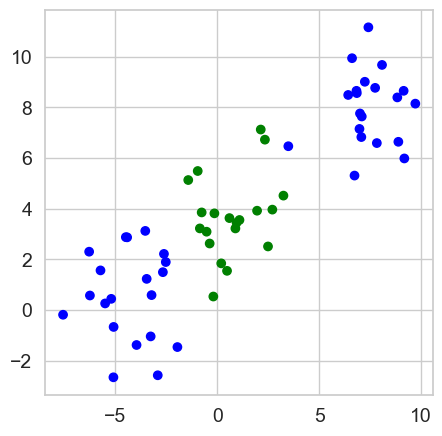

In [8]:
# generates data set (two Gaussians) for visualization purposes
X_h, y_h = make_blobs(n_samples=60, centers=3, cluster_std=(1.5,1.5,1.5), random_state=3)
y_h = np.where(y_h==2, 1, y_h)
xlim_h, ylim_h = get_boundaries(X_h)

fig = plt.figure(figsize=(5,5))
plt.scatter(X_h[:, 0], X_h[:, 1], c=y_h, cmap=cm);

- Solution:
    + Enlarge the space of features using different transformations, like $\vec{f}_1, \vec{f}_1^2, \vec{f}_1^3, \vec{f}_1\vec{f}_2, \vec{f}_2,\dots$
    + Fit a support-vector classifier in the enlarged space
- This procedure results in non-linear decision boundaries in the original space

## Kernels

- Polynomials (especially high-dimensional ones) get wild
rather fast
- The solution of the optimization problem is based only on computation of *dot products* of observations $\vec{a} \cdot \vec{b} = \sum{a_ib_i}$
- These dot products can be generalized by **kernel functions** $K$
- The problem can be represented as 
$ f(\vec{x}) = w_0 + \sum_{i} K(\vec{x},\vec{x}_i) $
- Intuition: *kernels quantify similarities between observations*
- Different kernels:
    + Linear kernels correspond to Pearson correlation
    + Polynomial kernels are more general
    + Radial kernels can be used to generate circular boundaries

## Example: Radial kernel
- Application of a radial kernel 
$K(x_i,x_j)=\text{exp}\left(-\gamma\sum_k(x_{ik}-x_{jk})^2\right)$, where 
    - $x_i$ and $x_j$ are observation vectors
    - $\gamma$ indicates the radius of a support vector "influence" - smaller values result in greater radius

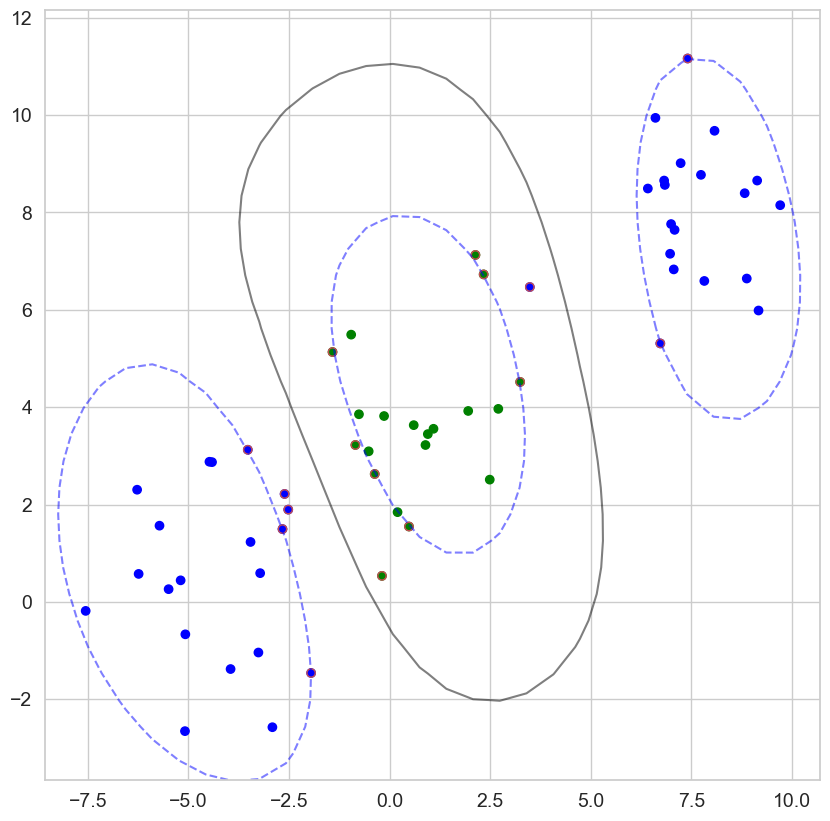

In [9]:
fig = plt.figure(figsize=(10,10))
plt.xlim(xlim_h)
plt.ylim(ylim_h)
plt.scatter(X_h[:, 0], X_h[:, 1], c=y_h, cmap=cm)

m = svm.SVC(kernel='rbf', C=1, degree=10, gamma=0.05)
m.fit(X_h, y_h)

plot(m, plt, xlim_h, ylim_h)

## SVM example

In [10]:
bc = pd.read_csv("data/breast-cancer.csv")
bc.head()

,recurrence,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no


In [11]:
bc.describe(include='all')

,recurrence,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
count,286,286,286,286,286,286,286.000000,286,286,286
unique,2,6,3,11,7,3,NaN,2,6,2
top,no-recurrence-events,50-59,premeno,30-34,0-2,no,NaN,left,left_low,no
freq,201,96,150,60,213,222,NaN,152,110,218
mean,NaN,NaN,NaN,NaN,NaN,NaN,2.048951,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,0.738217,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN


In [12]:
import sklearn.model_selection as sel
import sklearn.metrics as mt
from sklearn.preprocessing import OneHotEncoder, LabelBinarizer

bc = pd.read_csv("data/breast-cancer.csv")
y_bc = bc.pop("recurrence").values
X_bc = bc.values

In [13]:
ohe = OneHotEncoder()
X_bc = ohe.fit_transform(X_bc).toarray()

In [14]:
X_train, X_test, y_train, y_test = sel.train_test_split(X_bc, y_bc, test_size=0.25, random_state=123, stratify=y_bc)
m = svm.SVC(kernel='sigmoid', gamma='scale', C=0.85, 
            class_weight={'no-recurrence-events':.25, 'recurrence-events':.75})
m.fit(X_train, y_train)
y_pred = m.predict(X_test)
print(mt.classification_report(y_test, y_pred))

                      precision    recall  f1-score   support

no-recurrence-events       0.93      0.78      0.85        51
   recurrence-events       0.62      0.86      0.72        21

            accuracy                           0.81        72
           macro avg       0.78      0.82      0.79        72
        weighted avg       0.84      0.81      0.81        72



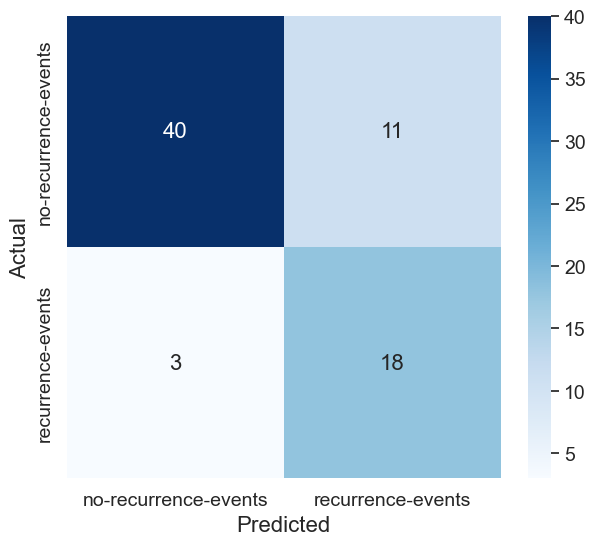

In [15]:
df_cm = pd.DataFrame(mt.confusion_matrix(y_test, y_pred), columns=['no-recurrence-events', 'recurrence-events'], 
                     index = ['no-recurrence-events', 'recurrence-events'])
plt.figure(figsize=(7,6))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
sns.heatmap(df_cm, cmap="Blues", annot=True, annot_kws={"size": 16});

Average F1 from 10-fold CV: 0.5229588964139049


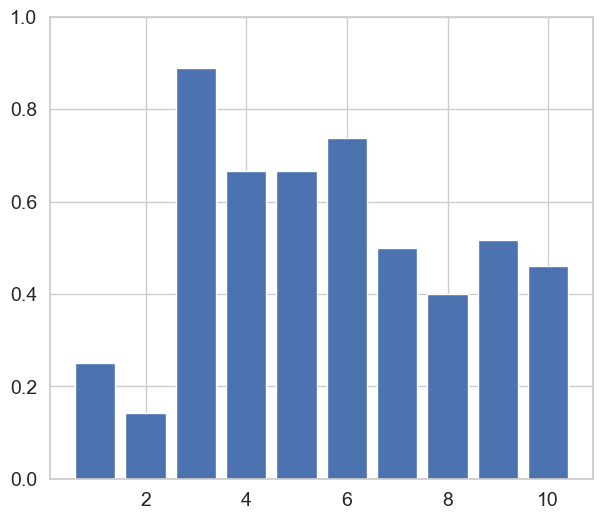

In [16]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score
y_l = LabelBinarizer().fit_transform(y_bc).flatten()

m = svm.SVC(kernel='rbf', gamma='scale', C=1, 
            class_weight={0:.25, 1:.75})
res = cross_validate(m, X_bc, y_l, cv=StratifiedKFold(n_splits=10),  scoring=["precision", 'recall', 'f1'])
print("Average F1 from 10-fold CV: {}".format(np.average(res['test_f1'])))
plt.figure(figsize=(7,6))
plt.bar(np.arange(1,11), res['test_f1'])
plt.ylim(0,1)
plt.show()